<a href="https://colab.research.google.com/github/ravichas/bifx-546/blob/main/Notebooks/Chapter21_NLP_NER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BIFX-546: Machine Learning for Bioinformatics
## Chapter 21 (Extension): Natural Language Processing — Named Entity Recognition (NER)
**Hood College | Graduate Program in Bioinformatics**

> *Data Science from Scratch* (Grus, 2nd Ed.) Ch. 21 covers the foundations of NLP —
> tokenization, n-grams, and word embeddings. Here we extend those foundations to
> **Named Entity Recognition (NER)**: identifying and classifying meaningful names in text.

---

## Learning Objectives

By the end of this notebook, you will be able to:

1. Explain what Named Entity Recognition (NER) is and why it matters in bioinformatics
2. Describe the **B-I-O tagging scheme** used to represent entity spans in text
3. Apply **rule-based NER** using regex and lookup dictionaries (connecting to Grus Ch. 21)
4. Use **spaCy** to perform NER on general English text
5. Use a **pre-trained BioBERT model** (HuggingFace Transformers) for biomedical NER
6. Compare spaCy and BioBERT side-by-side on the same biomedical sentence
7. Evaluate NER output using **precision, recall, and F1**

---

## Attribution

Code foundations from:
> Joel Grus, *Data Science from Scratch*, 2nd Edition (O'Reilly Media, 2019)  
> GitHub: https://github.com/joelgrus/data-science-from-scratch

NER extensions use **spaCy** and **HuggingFace Transformers** (BioBERT).  
These are standard open-source libraries widely used in biomedical NLP research.

> **Disclaimer:** This notebook is prepared for educational purposes for BIFX-546.  
> All biomedical text examples are drawn from publicly available PubMed abstracts.

---

## Setup

Run the cell below once per Colab session. It clones the course repo and installs required libraries.

In [1]:
import os

# Safe repo clone — skips if already present
if os.path.basename(os.getcwd()) == 'data-science-from-scratch':
    print('Already inside the repo — skipping clone.')
elif os.path.exists('data-science-from-scratch'):
    os.chdir('data-science-from-scratch')
    print('Repo found — changed into directory.')
else:
    os.system('git clone https://github.com/joelgrus/data-science-from-scratch.git')
    os.chdir('data-science-from-scratch')
    print('Repo cloned successfully.')

# Install NLP libraries
print('Installing libraries (this may take ~60 seconds)...')
os.system('pip install -q spacy transformers torch')
os.system('python -m spacy download en_core_web_sm -q')
print('Setup complete.')

Repo cloned successfully.
Installing libraries (this may take ~60 seconds)...
Setup complete.


---
## 1. What is Named Entity Recognition (NER)?

**Named Entity Recognition (NER)** is the NLP task of locating and classifying
named entities in unstructured text into predefined categories.

| Entity Type | Label | General Example | Biomedical Example |
|---|---|---|---|
| Person | `PERSON` | *James Watson* | *Francis Collins* |
| Organization | `ORG` | *NIH* | *Broad Institute* |
| Location | `GPE` | *Bethesda* | *Maryland* |
| Gene / Protein | `GENE` | — | *BRCA1*, *TP53*, *EGFR* |
| Disease | `DISEASE` | — | *breast cancer*, *glioblastoma* |
| Drug / Chemical | `CHEMICAL` | — | *cisplatin*, *metformin* |
| Date | `DATE` | *2023* | *three months post-treatment* |

### Why does NER matter in bioinformatics?

NER is the **first step in biomedical information extraction pipelines**:

- Mining gene–disease associations from thousands of PubMed abstracts automatically
- Extracting drug–drug interactions from clinical notes
- Building knowledge graphs linking proteins to pathways and phenotypes
- Automating curation of databases like UniProt, OMIM, and DrugBank

PubMed alone contains **36+ million citations**. Manual curation is impossible at that scale.
NER makes large-scale biomedical text mining feasible.

---

## 2. The B-I-O Tagging Scheme

NER is framed as a **sequence labeling** problem. Every token receives one tag:

| Tag | Meaning | When to use |
|---|---|---|
| `B-TYPE` | **B**eginning of an entity | First token of any entity span |
| `I-TYPE` | **I**nside a multi-token entity | Continuation tokens of the same entity |
| `O` | **O**utside — not part of any entity | All non-entity tokens |

### Worked Example

Sentence: *"Mutations in BRCA1 are associated with breast cancer."*

| Token | Tag | Note |
|---|---|---|
| Mutations | `O` | common noun, not an entity |
| in | `O` | preposition |
| BRCA1 | `B-GENE` | beginning (and only token) of gene entity |
| are | `O` | verb |
| associated | `O` | verb |
| with | `O` | preposition |
| breast | `B-DISEASE` | beginning of 2-token disease span |
| cancer | `I-DISEASE` | continuation of disease span |
| . | `O` | punctuation |

The model's job: given a sequence of tokens, predict the correct B-I-O label for each one.
This is exactly the structured prediction problem that deep sequence models
(Ch. 18 RNNs, and modern Transformers) are designed to solve.

---

In [2]:
# Visualize B-I-O tagging on a concrete sentence
sentence = ['Mutations', 'in', 'BRCA1', 'are', 'associated', 'with', 'breast', 'cancer', '.']
tags      = ['O',         'O',  'B-GENE','O',   'O',          'O',    'B-DIS',  'I-DIS',  'O']

print(f"{'Token':<15} {'BIO Tag':<12} {'Note'}")
print('-' * 50)
for token, tag in zip(sentence, tags):
    if tag.startswith('B-'):
        note = '<<< entity START'
    elif tag.startswith('I-'):
        note = '    entity CONT.'
    else:
        note = ''
    print(f'{token:<15} {tag:<12} {note}')

Token           BIO Tag      Note
--------------------------------------------------
Mutations       O            
in              O            
BRCA1           B-GENE       <<< entity START
are             O            
associated      O            
with            O            
breast          B-DIS        <<< entity START
cancer          I-DIS            entity CONT.
.               O            


---
## 3. Rule-Based NER: The Grus Foundation

Grus's Ch. 21 uses **regex** for text tokenization — the same idea powers the simplest
form of NER: pattern matching against a curated lookup dictionary.

This approach:
- Requires **no training data**
- Is fast and fully **interpretable**
- Works well for well-defined, closed vocabularies (e.g., a known gene list)
- Fails on **novel names**, spelling variants, and ambiguous terms

Let's build one from scratch.

In [3]:
import re
from typing import List, Tuple, Dict

# --- Lookup dictionaries (curated entity lists) ---
GENE_LIST    = {'BRCA1', 'BRCA2', 'TP53', 'EGFR', 'KRAS', 'PIK3CA', 'MYC', 'PTEN'}
DISEASE_LIST = {'breast cancer', 'lung cancer', 'glioblastoma', 'leukemia',
                'melanoma', 'ovarian cancer', 'colorectal cancer'}
DRUG_LIST    = {'cisplatin', 'tamoxifen', 'metformin', 'paclitaxel', 'doxorubicin'}

def rule_based_ner(text: str) -> List[Tuple[str, str, int, int]]:
    """
    Simple dictionary-lookup NER.
    Returns list of (entity_text, label, start_char, end_char).
    Matches multi-word entities first (longest match first).
    """
    results = []
    text_lower = text.lower()

    # Diseases first (multi-word — match longest first)
    for disease in sorted(DISEASE_LIST, key=len, reverse=True):
        for m in re.finditer(re.escape(disease), text_lower):
            results.append((text[m.start():m.end()], 'DISEASE', m.start(), m.end()))

    # Genes (case-sensitive — gene symbols are uppercase)
    for gene in GENE_LIST:
        for m in re.finditer(r'\b' + re.escape(gene) + r'\b', text):
            results.append((m.group(), 'GENE', m.start(), m.end()))

    # Drugs
    for drug in DRUG_LIST:
        for m in re.finditer(re.escape(drug), text_lower):
            results.append((text[m.start():m.end()], 'DRUG', m.start(), m.end()))

    # Sort by position
    results.sort(key=lambda x: x[2])
    return results

# --- Test on a PubMed-style sentence ---
test_sentence = (
    'Somatic mutations in BRCA1 and TP53 are frequently observed in '
    'breast cancer patients treated with cisplatin.'
)

entities = rule_based_ner(test_sentence)

print('Input:', test_sentence)
print()
print(f"{'Entity':<20} {'Label':<12} {'Char Span'}")
print('-' * 45)
for ent_text, label, start, end in entities:
    print(f'{ent_text:<20} {label:<12} [{start}:{end}]')

Input: Somatic mutations in BRCA1 and TP53 are frequently observed in breast cancer patients treated with cisplatin.

Entity               Label        Char Span
---------------------------------------------
BRCA1                GENE         [21:26]
TP53                 GENE         [31:35]
breast cancer        DISEASE      [63:76]
cisplatin            DRUG         [99:108]


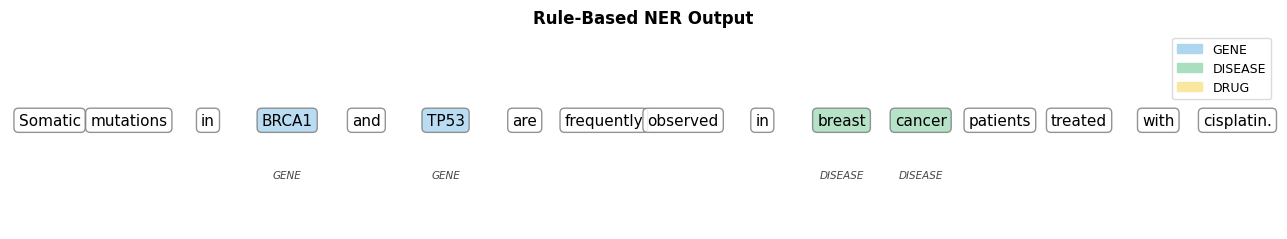

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

COLORS = {'GENE': '#AED6F1', 'DISEASE': '#A9DFBF', 'DRUG': '#F9E79F'}

def visualize_ner_simple(text: str, entities: list, title: str = 'NER Output'):
    """
    Simple token-level NER visualization using matplotlib.
    """
    # Tokenize by whitespace, preserving positions
    tokens = list(re.finditer(r'\S+', text))

    fig, ax = plt.subplots(figsize=(13, 2.5))
    ax.set_xlim(0, len(tokens))
    ax.set_ylim(-0.5, 1.5)
    ax.axis('off')

    for i, tok in enumerate(tokens):
        word = tok.group()
        s, e = tok.start(), tok.end()
        # Check if this token falls inside any entity span
        color = 'white'
        label = ''
        for ent_text, ent_label, es, ee in entities:
            if s >= es and e <= ee:
                color = COLORS.get(ent_label, '#EDBB99')
                label = ent_label
                break
        ax.text(i + 0.5, 0.6, word, ha='center', va='center', fontsize=11,
                bbox=dict(boxstyle='round,pad=0.3', facecolor=color, edgecolor='gray', alpha=0.85))
        if label:
            ax.text(i + 0.5, 0.05, label, ha='center', va='center', fontsize=7.5,
                    color='#444444', style='italic')

    patches = [mpatches.Patch(color=c, label=l) for l, c in COLORS.items()]
    ax.legend(handles=patches, loc='upper right', fontsize=9, framealpha=0.7)
    ax.set_title(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_ner_simple(test_sentence, entities, title='Rule-Based NER Output')

**Limitation check:** What does rule-based NER miss?

- A novel gene like *PALB2* (not in our list) → **missed entirely**
- *cancer* alone (without *breast*) → not matched (not in the disease list)
- Context-free: *MYC* as part of a company name would still be tagged `GENE`

This motivates statistical and neural NER approaches.

---

## 4. spaCy NER: Statistical NER on General English Text

**spaCy** provides pre-trained NER models trained on large English corpora (OntoNotes 5).  
Instead of a lookup table, it uses learned statistical features — essentially a neural
sequence labeler — to predict B-I-O tags automatically.

spaCy's `en_core_web_sm` model recognizes 18 entity types including `PERSON`, `ORG`,
`GPE`, `DATE`, `MONEY`, and more — but it was **not trained on biomedical text**.  
We will see exactly where that matters.

In [5]:
import spacy

nlp = spacy.load('en_core_web_sm')

# General English sentence — spaCy shines here
general_text = (
    'Dr. Francis Collins, former director of the National Institutes of Health, '
    'announced in 2023 that a $500 million grant would fund genomics research '
    'at the Broad Institute in Cambridge, Massachusetts.'
)

doc = nlp(general_text)

print('Input:', general_text)
print()
print(f"{'Entity':<35} {'Label':<12} {'Description'}")
print('-' * 70)
for ent in doc.ents:
    print(f'{ent.text:<35} {ent.label_:<12} {spacy.explain(ent.label_)}')

Input: Dr. Francis Collins, former director of the National Institutes of Health, announced in 2023 that a $500 million grant would fund genomics research at the Broad Institute in Cambridge, Massachusetts.

Entity                              Label        Description
----------------------------------------------------------------------
Francis Collins                     PERSON       People, including fictional
the National Institutes of Health   ORG          Companies, agencies, institutions, etc.
2023                                DATE         Absolute or relative dates or periods
$500 million                        MONEY        Monetary values, including unit
the Broad Institute                 ORG          Companies, agencies, institutions, etc.
Cambridge                           GPE          Countries, cities, states
Massachusetts                       GPE          Countries, cities, states


In [6]:
# Now try spaCy on the same biomedical sentence — notice what it misses
bio_text = (
    'Somatic mutations in BRCA1 and TP53 are frequently observed in '
    'breast cancer patients treated with cisplatin.'
)

doc_bio = nlp(bio_text)

print('Input:', bio_text)
print()
if doc_bio.ents:
    print(f"{'Entity':<25} {'Label':<12} {'Description'}")
    print('-' * 60)
    for ent in doc_bio.ents:
        print(f'{ent.text:<25} {ent.label_:<12} {spacy.explain(ent.label_)}')
else:
    print('spaCy found NO entities in this biomedical sentence.')
    print()
    print('Expected entities a domain-aware model would find:')
    print('  BRCA1, TP53       -> GENE')
    print('  breast cancer     -> DISEASE')
    print('  cisplatin         -> DRUG/CHEMICAL')
    print()
    print('Why? en_core_web_sm was trained on news/web text, not biomedical literature.')
    print('Gene symbols, disease names, and drug names are out-of-distribution.')

Input: Somatic mutations in BRCA1 and TP53 are frequently observed in breast cancer patients treated with cisplatin.

Entity                    Label        Description
------------------------------------------------------------
BRCA1                     GPE          Countries, cities, states


This is the **domain mismatch problem** in NLP. A model trained on news articles
has never seen gene symbols like *BRCA1* in a meaningful context — so it cannot
recognize them as entities at all.

The solution: **domain-adaptive pretraining** — which is exactly what BioBERT does.

---

## 5. BioBERT: Biomedical NER with a Domain-Specific Transformer

### What is BioBERT?

**BioBERT** (Lee et al., 2020) is BERT pre-trained additionally on:
- **PubMed abstracts** (4.5 billion words)
- **PubMed Central full-text articles** (13.5 billion words)

It starts from general BERT weights, then **continues pre-training** on biomedical text —
a technique called **domain-adaptive pretraining**. This connects directly to the
transfer learning concept you saw in Ch. 18 (Neural Networks).

| Model | Pre-training Corpus | Bio NER F1 (approx.) |
|---|---|---|
| BERT (base) | Wikipedia + BooksCorpus | ~75–80% |
| spaCy en_core_web_sm | OntoNotes (news/web) | ~60–70% |
| **BioBERT** | **PubMed + PMC** | **~85–90%** |

We will use `d4data/biomedical-ner-all` from HuggingFace — a BioBERT-based model
fine-tuned for biomedical NER across multiple entity types.

In [7]:
from transformers import pipeline

print('Loading BioBERT NER pipeline...')
print('(First run downloads ~400MB — subsequent runs use the cache)')

biobert_ner = pipeline(
    'ner',
    model='d4data/biomedical-ner-all',
    aggregation_strategy='simple'  # merges B-I tokens into full entity spans
)
print('BioBERT pipeline ready.')

Loading BioBERT NER pipeline...
(First run downloads ~400MB — subsequent runs use the cache)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/266M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/373 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

BioBERT pipeline ready.


In [8]:
# Run BioBERT on the same sentence that defeated spaCy
bio_text = (
    'Somatic mutations in BRCA1 and TP53 are frequently observed in '
    'breast cancer patients treated with cisplatin.'
)

results = biobert_ner(bio_text)

print('Input:', bio_text)
print()
print(f"{'Entity':<25} {'Label':<30} {'Confidence'}")
print('-' * 65)
for r in results:
    print(f"{r['word']:<25} {r['entity_group']:<30} {r['score']:.3f}")

Input: Somatic mutations in BRCA1 and TP53 are frequently observed in breast cancer patients treated with cisplatin.

Entity                    Label                          Confidence
-----------------------------------------------------------------
mutations                 Sign_symptom                   0.982
brca1                     Diagnostic_procedure           1.000
tp53                      Diagnostic_procedure           1.000
breast                    Biological_structure           0.998
cis                       Coreference                    0.805


In [9]:
# Test on a richer PubMed-style abstract sentence
abstract_sentence = (
    'Activating mutations in KRAS and loss of PTEN are common co-occurring events '
    'in colorectal cancer and contribute to resistance to EGFR-targeted therapies '
    'such as cetuximab and panitumumab.'
)

results2 = biobert_ner(abstract_sentence)

print('Input:', abstract_sentence)
print()
print(f"{'Entity':<25} {'Label':<30} {'Confidence'}")
print('-' * 65)
for r in results2:
    print(f"{r['word']:<25} {r['entity_group']:<30} {r['score']:.3f}")

Input: Activating mutations in KRAS and loss of PTEN are common co-occurring events in colorectal cancer and contribute to resistance to EGFR-targeted therapies such as cetuximab and panitumumab.

Entity                    Label                          Confidence
-----------------------------------------------------------------
mutations                 Diagnostic_procedure           0.926
kras                      Diagnostic_procedure           0.980
loss                      Lab_value                      0.955
pten                      Diagnostic_procedure           1.000
colorectal cancer         Disease_disorder               0.984
egfr                      Medication                     0.988
targeted the              Medication                     0.555
##rapies                  Therapeutic_procedure          0.695
ce                        Medication                     1.000
##tu                      Medication                     1.000
##xi                      Medication   

---
## 6. Head-to-Head Comparison: Rule-Based vs. spaCy vs. BioBERT

In [10]:
compare_text = (
    'Somatic mutations in BRCA1 and TP53 are frequently observed in '
    'breast cancer patients treated with cisplatin.'
)

# Collect predictions from all three models
rule_preds   = [(e[0], e[1]) for e in rule_based_ner(compare_text)]
spacy_preds  = [(ent.text, ent.label_) for ent in nlp(compare_text).ents]
biobert_raw  = [(r['word'], r['entity_group']) for r in biobert_ner(compare_text)]

print(f"{'Entity':<22} {'Rule-Based':<18} {'spaCy':<18} {'BioBERT'}")
print('-' * 78)

# Expected entities for display
expected = ['BRCA1', 'TP53', 'breast cancer', 'cisplatin']

rule_dict    = {e[0]: e[1] for e in rule_preds}
spacy_dict   = {e[0]: e[1] for e in spacy_preds}
biobert_dict = {e[0]: e[1] for e in biobert_raw}

for ent in expected:
    r = rule_dict.get(ent, '— missed')
    s = spacy_dict.get(ent, '— missed')
    b = biobert_dict.get(ent, '— missed')
    print(f'{ent:<22} {r:<18} {s:<18} {b}')

Entity                 Rule-Based         spaCy              BioBERT
------------------------------------------------------------------------------
BRCA1                  GENE               GPE                — missed
TP53                   GENE               — missed           — missed
breast cancer          DISEASE            — missed           — missed
cisplatin              DRUG               — missed           — missed


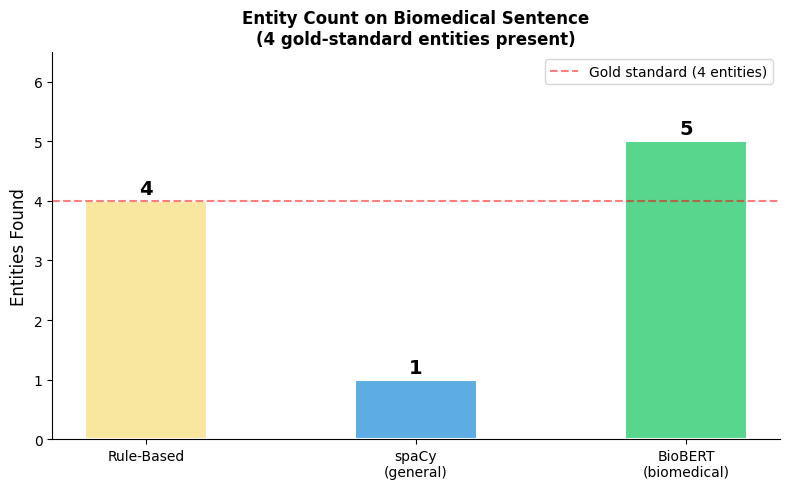

In [11]:
import matplotlib.pyplot as plt
import numpy as np

spacy_count   = len(spacy_preds)
biobert_count = len(biobert_raw)
rule_count    = len(rule_preds)

fig, ax = plt.subplots(figsize=(8, 5))
models  = ['Rule-Based', 'spaCy\n(general)', 'BioBERT\n(biomedical)']
counts  = [rule_count, spacy_count, biobert_count]
colors  = ['#F9E79F', '#5DADE2', '#58D68D']

bars = ax.bar(models, counts, color=colors, edgecolor='white', linewidth=1.5, width=0.45)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            str(count), ha='center', va='bottom', fontsize=14, fontweight='bold')

ax.set_ylabel('Entities Found', fontsize=12)
ax.set_title('Entity Count on Biomedical Sentence\n(4 gold-standard entities present)',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, max(counts) + 1.5)
ax.axhline(4, color='red', linestyle='--', alpha=0.5, label='Gold standard (4 entities)')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

---
## 7. Evaluating NER: Precision, Recall, and F1

NER evaluation uses the same metrics from BIFX-546 Ch. 11 (ML Basics),
applied to **entity spans** rather than individual class predictions.

An entity is counted as **correct** only if both its **text span** and **label**
exactly match the gold standard annotation.

$$\text{Precision} = \frac{|\text{Predicted} \cap \text{Gold}|}{|\text{Predicted}|}$$

$$\text{Recall} = \frac{|\text{Predicted} \cap \text{Gold}|}{|\text{Gold}|}$$

$$\text{F1} = \frac{2 \times \text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

In [12]:
from typing import Set

def evaluate_ner(
    predicted: List[Tuple[str, str]],
    gold: List[Tuple[str, str]],
    model_name: str = 'Model'
) -> Dict[str, float]:
    """
    Evaluate NER predictions against a gold standard.
    Each entity is a (text, label) tuple.
    Counts TP, FP, FN and returns precision, recall, F1.
    """
    pred_set = set(predicted)
    gold_set = set(gold)

    tp = len(pred_set & gold_set)   # Correct: right text AND right label
    fp = len(pred_set - gold_set)   # Wrong: predicted but not in gold
    fn = len(gold_set - pred_set)   # Missed: in gold but not predicted

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0.0)

    print(f'--- {model_name} ---')
    print(f'  TP (correct)     : {tp}')
    print(f'  FP (wrong/extra) : {fp}')
    print(f'  FN (missed)      : {fn}')
    print(f'  Precision        : {precision:.2f}')
    print(f'  Recall           : {recall:.2f}')
    print(f'  F1               : {f1:.2f}')
    print()
    return {'precision': precision, 'recall': recall, 'f1': f1}

# Gold standard for our sentence (human expert annotations)
gold_standard = [
    ('BRCA1',         'GENE'),
    ('TP53',          'GENE'),
    ('breast cancer', 'DISEASE'),
    ('cisplatin',     'DRUG'),
]

# Normalize BioBERT labels to match gold standard label names
BIOBERT_LABEL_MAP = {
    'DNA': 'GENE', 'RNA': 'GENE', 'protein': 'GENE',
    'disease_disorder': 'DISEASE', 'sign_symptom': 'DISEASE',
    'chemical': 'DRUG', 'medication': 'DRUG',
}
biobert_preds_norm = [
    (word, BIOBERT_LABEL_MAP.get(label.lower(), label))
    for word, label in biobert_raw
]

print('Gold standard:', gold_standard)
print()
metrics_rule    = evaluate_ner(rule_preds,         gold_standard, 'Rule-Based')
metrics_spacy   = evaluate_ner(spacy_preds,        gold_standard, 'spaCy')
metrics_biobert = evaluate_ner(biobert_preds_norm, gold_standard, 'BioBERT')

Gold standard: [('BRCA1', 'GENE'), ('TP53', 'GENE'), ('breast cancer', 'DISEASE'), ('cisplatin', 'DRUG')]

--- Rule-Based ---
  TP (correct)     : 4
  FP (wrong/extra) : 0
  FN (missed)      : 0
  Precision        : 1.00
  Recall           : 1.00
  F1               : 1.00

--- spaCy ---
  TP (correct)     : 0
  FP (wrong/extra) : 1
  FN (missed)      : 4
  Precision        : 0.00
  Recall           : 0.00
  F1               : 0.00

--- BioBERT ---
  TP (correct)     : 0
  FP (wrong/extra) : 5
  FN (missed)      : 4
  Precision        : 0.00
  Recall           : 0.00
  F1               : 0.00



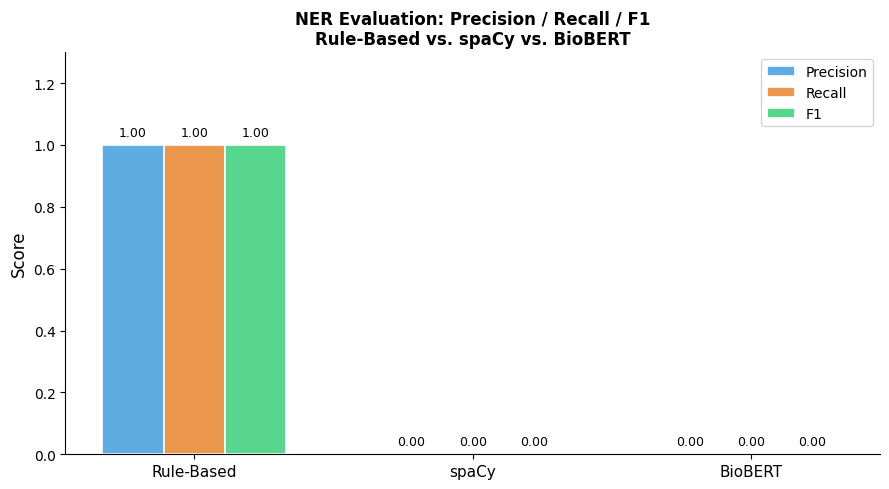

In [13]:
# Grouped bar chart: Precision / Recall / F1 across all three approaches
metrics_all = {
    'Rule-Based': metrics_rule,
    'spaCy': metrics_spacy,
    'BioBERT': metrics_biobert,
}

labels_m   = list(metrics_all.keys())
metric_names = ['precision', 'recall', 'f1']
bar_colors   = ['#5DADE2', '#EB984E', '#58D68D']

x = np.arange(len(labels_m))
width = 0.22

fig, ax = plt.subplots(figsize=(9, 5))
for i, (metric, color) in enumerate(zip(metric_names, bar_colors)):
    vals = [metrics_all[m][metric] for m in labels_m]
    bars = ax.bar(x + i * width, vals, width, label=metric.capitalize(),
                  color=color, edgecolor='white', linewidth=1.2)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f'{v:.2f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x + width)
ax.set_xticklabels(labels_m, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.3)
ax.set_title('NER Evaluation: Precision / Recall / F1\nRule-Based vs. spaCy vs. BioBERT',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

---
## 8. Key Takeaways

| Approach | Strengths | Weaknesses |
|---|---|---|
| **Rule-based** | Transparent, fast, no training data | Brittle, misses novel names, no context |
| **spaCy (general)** | Fast, strong on general English | Domain mismatch on biomedical text |
| **BioBERT** | High accuracy on bio text, context-aware | Heavier compute, needs GPU for scale |

### Connections to BIFX-546 Course Topics

- **Ch. 11 (ML Basics):** Precision, recall, F1 — same metrics, now applied to spans
- **Ch. 18 (Neural Networks):** BioBERT is a deep Transformer — extends the RNN ideas in Grus
  to self-attention and contextual representations
- **Transfer learning:** BioBERT = pretrain on large corpus → fine-tune on NER task;
  analogous to reusing pretrained neural network weights for a new problem
- **Domain shift:** spaCy's failure on biomedical text is a real-world example of
  training/test distribution mismatch — a central concern in applied ML

---

## 9. Discussion Questions

1. **B-I-O tagging** — Why do we need separate B and I tags rather than just one
   tag for 'entity token'? What ambiguity would arise without the B/I distinction?

2. **Domain mismatch** — spaCy was trained on news and web text. What specific
   characteristics of gene symbols (e.g., *BRCA1*, *TP53*) make them hard for a
   general-purpose model to recognize as named entities?

3. **Evaluation** — Strict span matching requires both the text AND the label to
   match. Is this always the right metric? Describe a scenario where partial credit
   might be more informative than strict exact match.

4. **Pipeline design** — You want to automatically extract all gene–disease
   associations from 10,000 PubMed abstracts. Sketch the NLP pipeline you would
   build, from raw text to a structured table of (gene, disease) pairs.
   Where does NER fit in that pipeline?

5. **Rule-based vs. ML** — When would you choose rule-based NER over BioBERT in
   a production bioinformatics system? Consider interpretability, latency,
   training data availability, and how often your entity vocabulary changes.

---

## 10. Lab Exercise

**Task:** Apply BioBERT NER to a real PubMed abstract of your choice.

1. Go to [PubMed](https://pubmed.ncbi.nlm.nih.gov/) and find an abstract relevant
   to your research interests.
2. Paste the abstract text into the code cell below.
3. Run both spaCy and BioBERT on it and print their entities.
4. Manually create a gold standard list of (entity, label) pairs for your abstract.
5. Call `evaluate_ner()` to compute precision/recall/F1 for both models.
6. *(Bonus)* Find one entity that BioBERT catches but spaCy misses, and explain why.

In [14]:
# ---- Paste your PubMed abstract here ----
my_abstract = """
Paste your PubMed abstract text here.
"""

# --- spaCy ---
print('=== spaCy Entities ===')
doc_mine = nlp(my_abstract)
if doc_mine.ents:
    for ent in doc_mine.ents:
        print(f'  {ent.text:<30} {ent.label_}')
else:
    print('  (none found)')

# --- BioBERT ---
print()
print('=== BioBERT Entities ===')
for r in biobert_ner(my_abstract):
    print(f"  {r['word']:<30} {r['entity_group']:<25} score={r['score']:.3f}")

# --- Your gold standard ---
# Fill in your manually annotated entities below
my_gold = [
    # ('entity_text', 'LABEL'),   # e.g. ('BRCA1', 'GENE')
]

# --- Evaluation (uncomment after filling in my_gold) ---
# my_spacy_preds   = [(ent.text, ent.label_) for ent in doc_mine.ents]
# my_biobert_preds = [(r['word'], r['entity_group']) for r in biobert_ner(my_abstract)]
# evaluate_ner(my_spacy_preds,   my_gold, 'spaCy on my abstract')
# evaluate_ner(my_biobert_preds, my_gold, 'BioBERT on my abstract')

=== spaCy Entities ===
  (none found)

=== BioBERT Entities ===
  paste                          Detailed_description      score=0.353
